<a href="https://colab.research.google.com/github/tluong1507/TrinhLuong_DTSC3020_Fall2026/blob/main/DTSC3020_Week6_Lesson5_Functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<style>
.jp-RenderedHTMLCommon h1 { color: #0b6b3a; border-bottom: 2px solid #dcefe5; padding-bottom: 6px; }
.jp-RenderedHTMLCommon h2 { color: #0e5f43; margin-top: 28px; }
.jp-RenderedHTMLCommon h3 { color: #205b85; }
.callout { border-left: 7px solid #0b6b3a; background: #f3fbf5; padding: 14px 18px; margin: 16px 0; border-radius: 8px; }
.warning { border-left: 7px solid #b45309; background: #fff8e6; padding: 14px 18px; margin: 16px 0; border-radius: 8px; }
.activity { border-left: 7px solid #2563eb; background: #f2f6ff; padding: 14px 18px; margin: 16px 0; border-radius: 8px; }
.checkpoint { border-left: 7px solid #7c3aed; background: #f8f5ff; padding: 14px 18px; margin: 16px 0; border-radius: 8px; }
.quiz { border: 1px solid #d8e2ea; background: #fbfdff; padding: 14px 18px; margin: 16px 0; border-radius: 10px; }
.figure { margin: 18px 0 24px 0; padding: 8px; background: #ffffff; border: 1px solid #d8e2ea; border-radius: 14px; }
.figcap { font-size: 0.9em; color: #52616b; margin-top: 6px; }
</style>


# DTSC 3020: Introduction to Computation with Python
## Week 6 Lecture — Lesson 5: Functions

**Instructor:** Dr. Haihua Chen  
**Department of Data Science, University of North Texas**

<div class="callout">
<b>Big idea:</b> Functions help us organize code into small, reusable pieces. This week focuses on defining and calling functions, working with arguments and return values, using selected built-in and utility functions, applying regular expressions, and introducing recursion and lambda expressions.
</div>

## Learning Objectives

By the end of Week 6, students should be able to:

1. Define and call Python functions to organize and reuse code.
2. Use function parameters, arguments, and return values in simple programs.
3. Apply positional, keyword, default, `*args`, and `**kwargs` arguments.
4. Use common Python built-in functions, including `zip()` and `repr()`.
5. Explain the purpose and potential risks of `eval()` and `exec()`.
6. Use regular expression functions for simple text searching, matching, extraction, and replacement.
7. Explain and apply basic recursion, including the use of a base case.
8. Create and use simple lambda expressions.
9. Write simple programs that use functions to solve practical programming problems.

## Week 6 Roadmap

1. Why functions matter
2. Function arguments
3. Built-in functions
4. `zip()`, `repr()`, `eval()`, and `exec()`
5. Regular expression functions
6. Recursion and lambda expressions
7. Applied examples and practice

# Part 1. Why Functions Matter

A function is a reusable block of code that performs a specific task. Instead of repeating the same code many times, we can write a function once and call it whenever we need it.

**Assigned reading:** [Introduction to Function — DataFlair](https://data-flair.training/blogs/python-function/)

Functions help us:

- Reduce repeated code
- Make programs easier to read
- Break large problems into smaller tasks
- Test and debug code more easily
- Reuse logic across projects
- Collaborate with others more effectively


## More Detail: Function Design Principles

A good function should usually do **one clear job**. This is sometimes called the **single-responsibility principle**. In beginner Python, a useful way to design a function is to ask:

1. What information does the function need?
2. What should the function do with that information?
3. Should the function print something, return something, or both?
4. Can I test this function with a few simple examples?

For this course, students should prefer functions that are short, clearly named, and easy to test.


<div class="figure">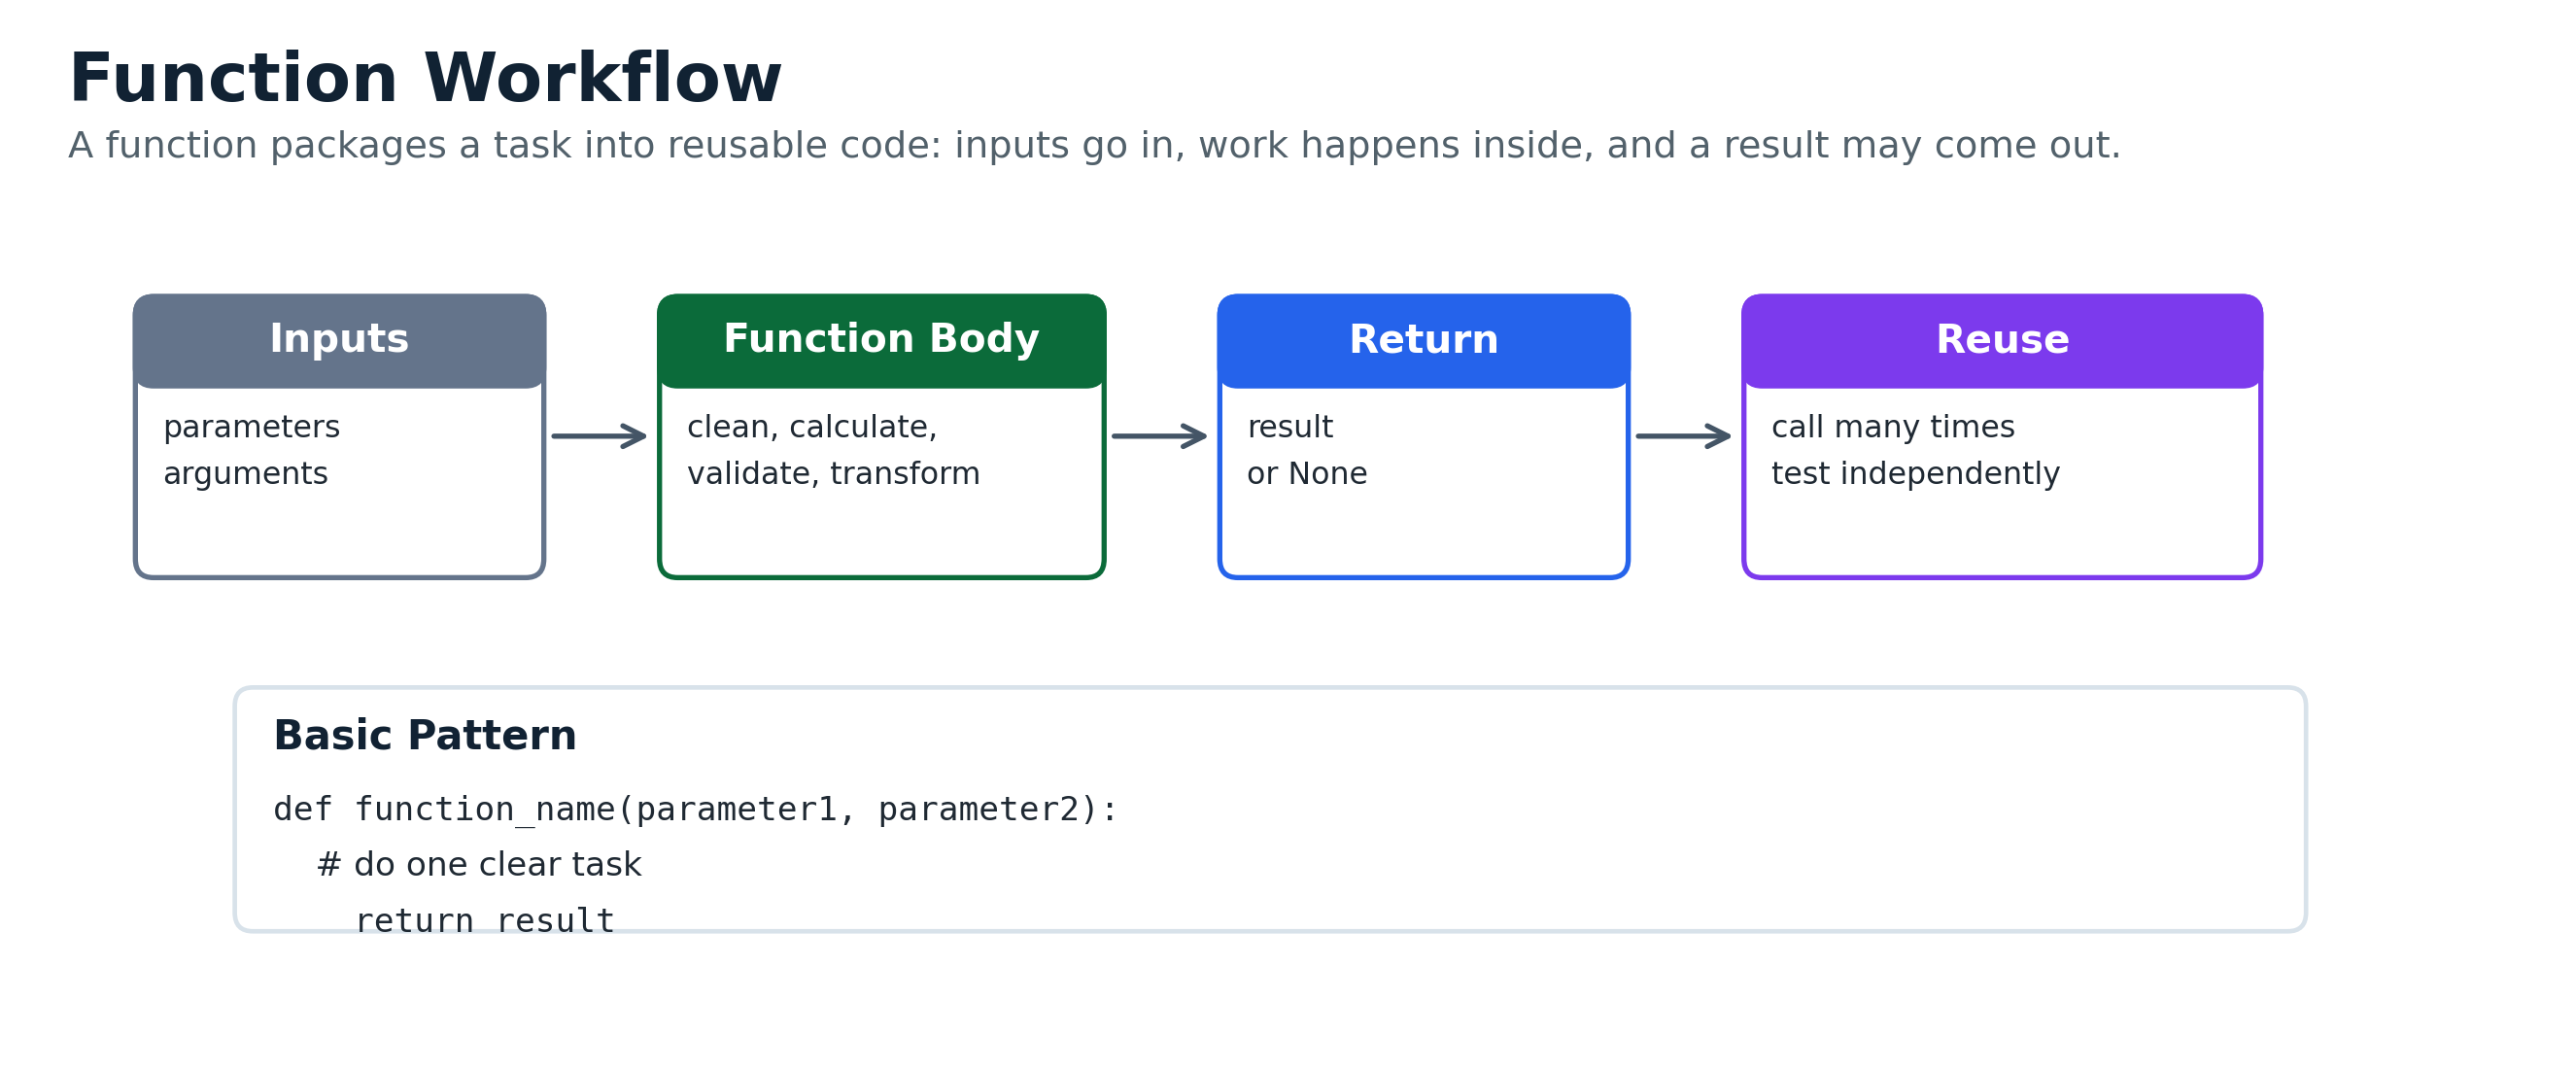<p class="figcap">Function workflow: input, body, return, and reuse.</p></div>

## Defining and Calling a Function


In [ ]:
def greet_student(name):
    print(f"Welcome to DTSC 3020, {name}!")

greet_student("Alice")
greet_student("Ben")

## Return Values

A function may return a result. This allows the result to be stored, reused, or passed into another function.


## Print vs. Return

A common beginner mistake is confusing `print()` and `return`.

| Concept | What it does | When to use |
|---|---|---|
| `print()` | Displays output to the screen | When you want the user to see something |
| `return` | Sends a value back to the caller | When you want to reuse the result later |

In most real programs, functions should often **return values** rather than only printing them.


In [ ]:
def calculate_percentage(earned_points, total_points):
    percentage = earned_points / total_points * 100
    return percentage

score = calculate_percentage(45, 50)
print(score)

## Docstrings

A docstring explains what a function does. It is placed as the first statement inside the function.


In [ ]:
def calculate_percentage(earned_points, total_points):
    """Return the percentage score from earned and total points."""
    return earned_points / total_points * 100

print(calculate_percentage.__doc__)

## Placeholder Functions with pass

Sometimes we plan a function before implementing it. `pass` keeps the function syntactically valid.


In [ ]:
def future_feature():
    pass

future_feature()
print("The placeholder function ran without error.")

# Part 2. Function Arguments

**Assigned reading:** [Function Arguments — DataFlair](https://data-flair.training/blogs/python-function-arguments/)

Arguments are the values passed into a function. Python supports several argument styles.


## More Detail: Parameters vs. Arguments

These two terms are closely related but not identical:

- A **parameter** is the variable name listed in the function definition.
- An **argument** is the actual value passed into the function when it is called.

Example:

```python
def greet(name):      # name is a parameter
    print(name)

greet("Alice")        # "Alice" is an argument
```

This distinction becomes especially important when learning default arguments, keyword arguments, `*args`, and `**kwargs`.


<div class="figure">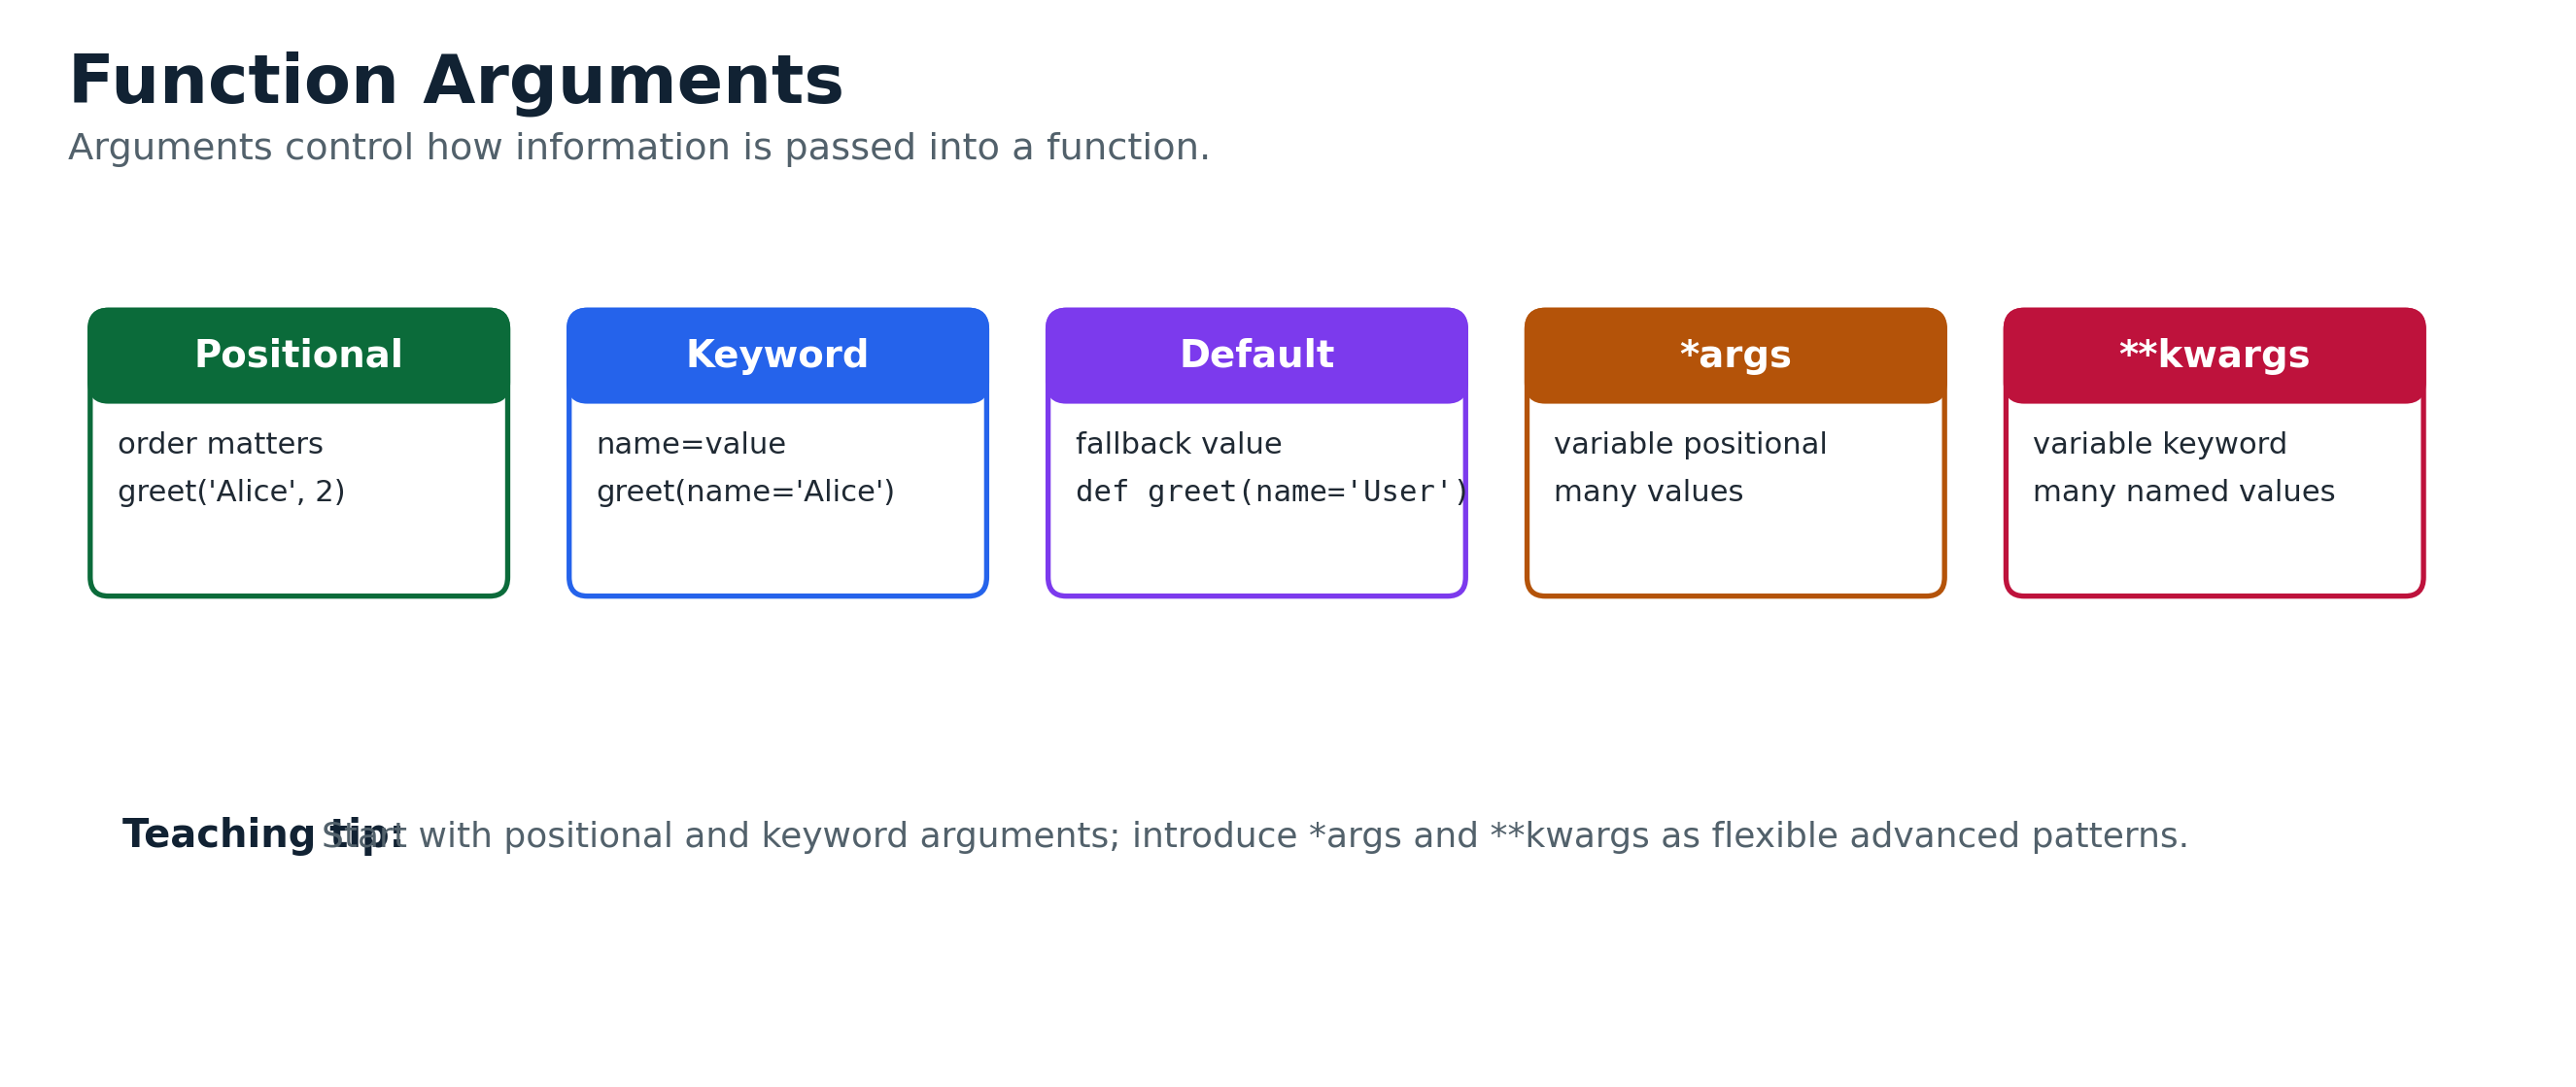<p class="figcap">Common function argument types.</p></div>

## Positional Arguments


In [ ]:
def introduce(name, major):
    print(f"{name} is majoring in {major}.")

introduce("Alice", "Data Science")

## Keyword Arguments


In [ ]:
def introduce(name, major):
    print(f"{name} is majoring in {major}.")

introduce(major="Data Science", name="Alice")

## Default Arguments


In [ ]:
def greet(name="student"):
    print(f"Hello, {name}!")

greet()
greet("Alice")

## *args and **kwargs

`*args` collects extra positional arguments.  
`**kwargs` collects extra keyword arguments.


## Common Pitfall: Mutable Default Arguments

Avoid using mutable values such as lists or dictionaries as default arguments.

Risky pattern:

```python
def add_item(item, items=[]):
    items.append(item)
    return items
```

Safer pattern:

```python
def add_item(item, items=None):
    if items is None:
        items = []
    items.append(item)
    return items
```

This is an important professional coding habit.


In [ ]:
def summarize_scores(*scores):
    return sum(scores) / len(scores)

print(summarize_scores(90, 85, 95))

def print_profile(**profile):
    for key, value in profile.items():
        print(key, ":", value)

print_profile(name="Alice", major="Data Science", score=95)

# Part 3. Built-In Functions

**Assigned reading:** [Built-In Functions — DataFlair](https://data-flair.training/blogs/python-built-in-functions/)

Built-in functions are available in Python without importing anything.


## More Detail: Why Built-In Functions Matter

Built-in functions are part of Python's everyday toolkit. Before writing custom code, ask whether a built-in function already solves the problem.

Examples:

- Use `len()` instead of manually counting items.
- Use `sum()` instead of manually adding values in a loop.
- Use `sorted()` instead of writing your own sorting algorithm.
- Use `enumerate()` when you need both index and value.
- Use `zip()` when you need to pair related sequences.

This helps students write shorter, clearer, and more reliable code.


<div class="figure">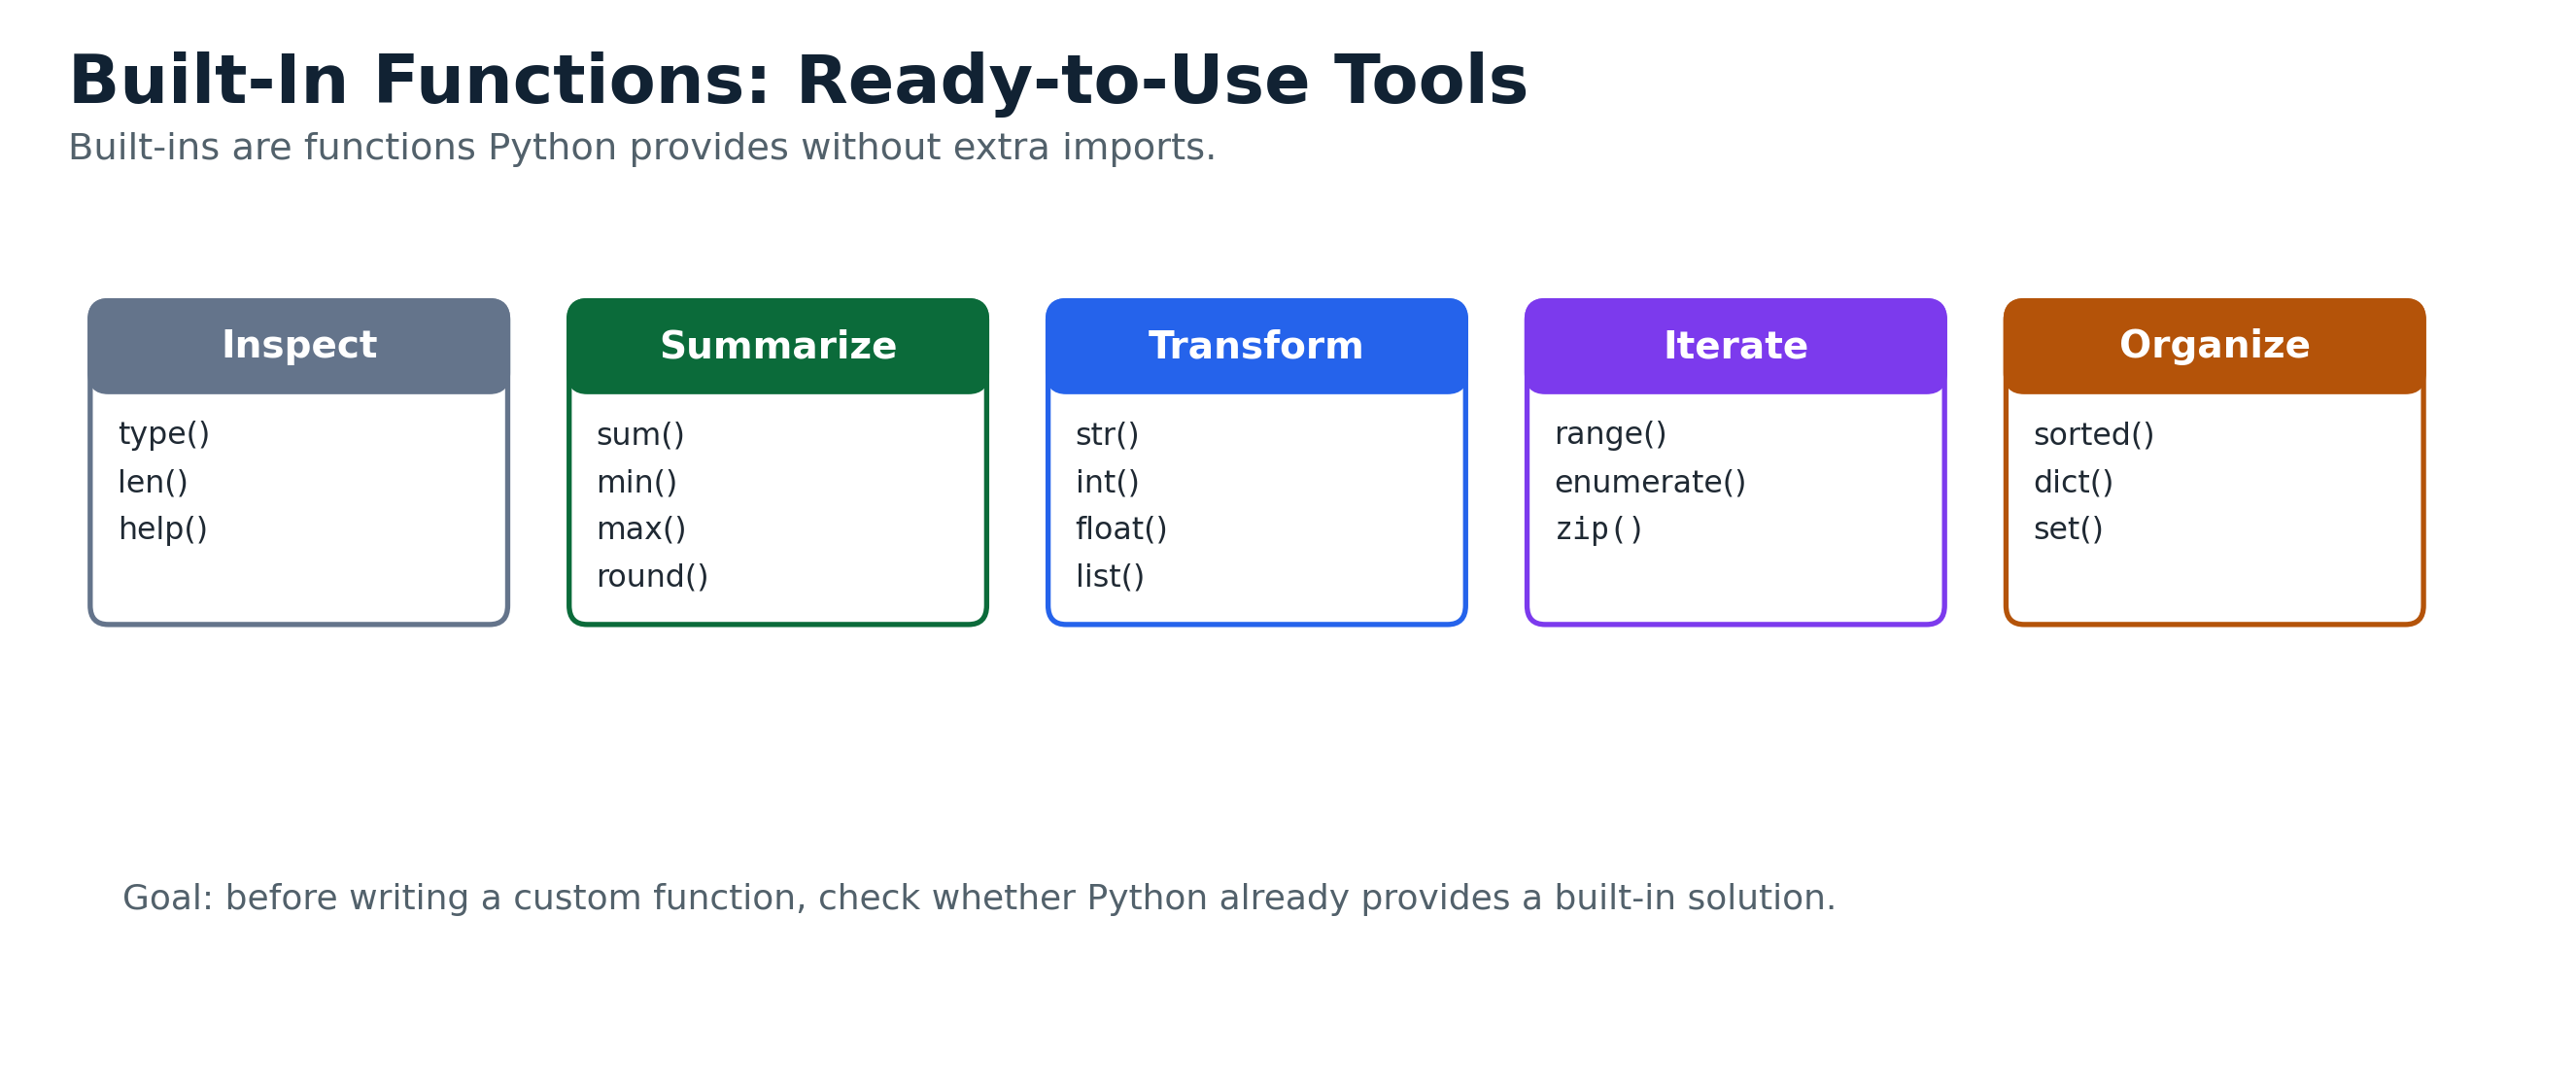<p class="figcap">Common built-in functions grouped by purpose.</p></div>

In [ ]:
scores = [88, 92, 79, 95, 100]

print("Length:", len(scores))
print("Total:", sum(scores))
print("Minimum:", min(scores))
print("Maximum:", max(scores))
print("Sorted:", sorted(scores))
print("Rounded average:", round(sum(scores) / len(scores), 2))

## Real Application Example: Quick Data Summary


In [ ]:
responses = ["Python", "AI", "Data Science", "Python"]

unique_responses = set(responses)

print("Number of responses:", len(responses))
print("Unique responses:", unique_responses)
print("Number of unique responses:", len(unique_responses))

# Part 4. zip(), repr(), eval(), and exec()

**Assigned readings:**  
- [Zip Function — DataFlair](https://data-flair.training/blogs/python-zip-function/)  
- [repr Function — DataFlair](https://data-flair.training/blogs/python-repr-function/)  
- [eval Function — DataFlair](https://data-flair.training/blogs/python-eval-function/)  
- [exec Function — DataFlair](https://data-flair.training/blogs/python-exec-function/)


## More Detail: When to Use These Functions

| Function | Main purpose | Beginner recommendation |
|---|---|---|
| `zip()` | Pair items from multiple sequences | Very useful and safe |
| `repr()` | Show developer-friendly object representation | Useful for debugging |
| `eval()` | Evaluate a string as a Python expression | Avoid with untrusted input |
| `exec()` | Execute a string as Python code | Avoid unless you fully understand the risk |

For AI-era programming, the most important message is: **never blindly run AI-generated code through `eval()` or `exec()`**.


<div class="figure">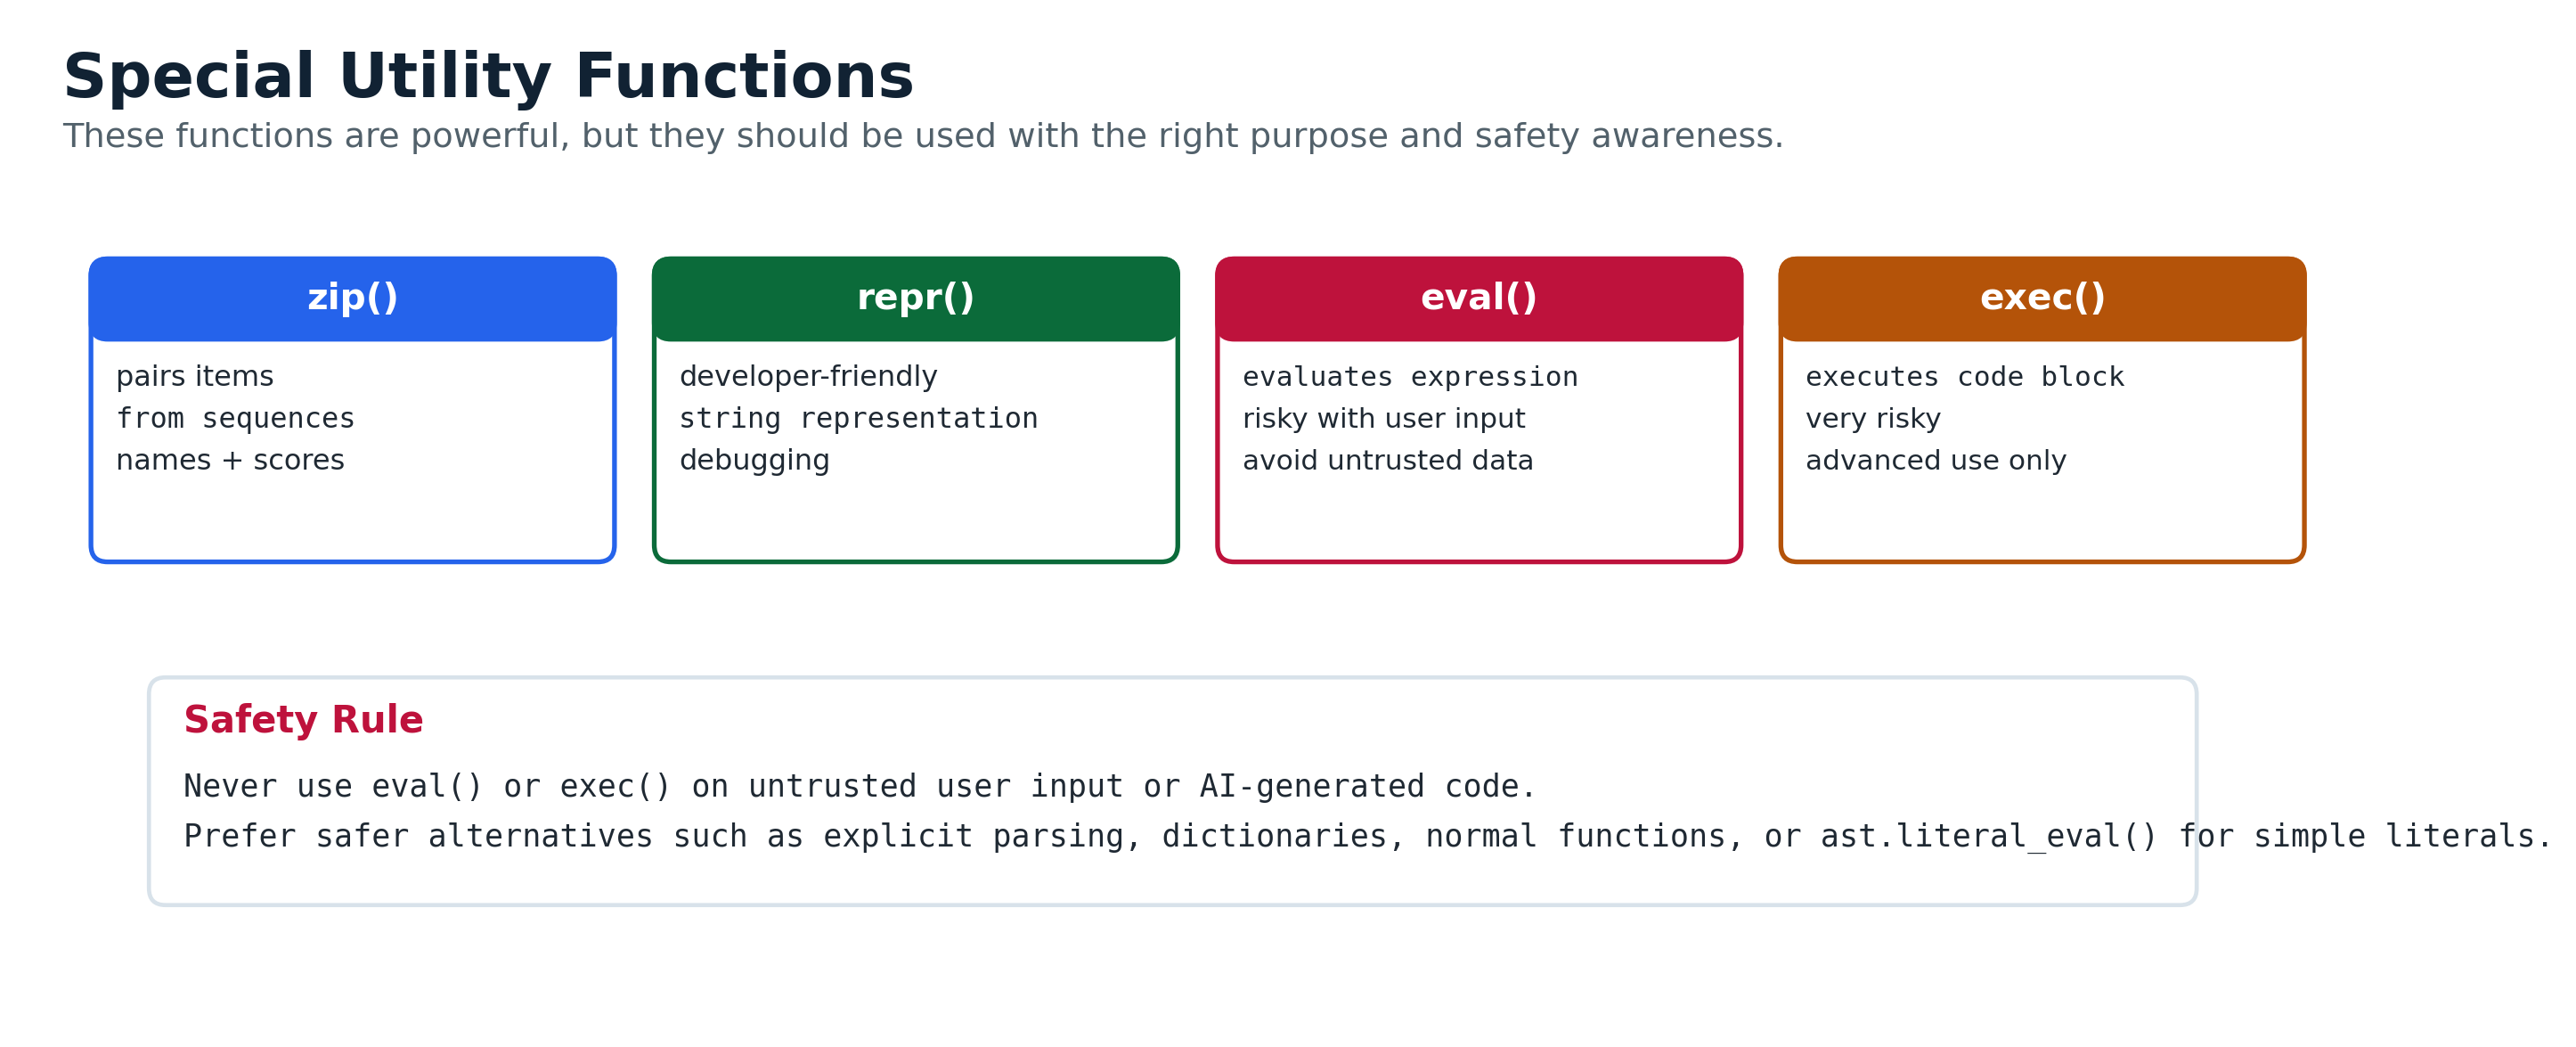<p class="figcap">Special utility functions and safety considerations.</p></div>

## zip(): Pairing Sequences


## Important Note: zip() Stops at the Shortest Sequence

If the sequences have different lengths, `zip()` stops when the shortest sequence ends. This behavior is useful, but students should be aware of it.


In [ ]:
names = ["Alice", "Ben", "Carla"]
scores = [95, 88]

for name, score in zip(names, scores):
    print(name, score)

print("Carla is not printed because scores has only two items.")

In [ ]:
names = ["Alice", "Ben", "Carla"]
scores = [95, 88, 91]

for name, score in zip(names, scores):
    print(name, "earned", score)

## Creating a Dictionary with zip()


In [ ]:
names = ["Alice", "Ben", "Carla"]
scores = [95, 88, 91]

gradebook = dict(zip(names, scores))
print(gradebook)

## repr(): Developer-Friendly Representation


In [ ]:
message = "Hello\nWorld"

print("Using print():")
print(message)

print("\nUsing repr():")
print(repr(message))

## eval(): Evaluate an Expression

`eval()` can evaluate a string as a Python expression. It is powerful but risky.


In [ ]:
expression = "2 + 3 * 4"
result = eval(expression)

print(result)

<div class="warning">
<b>Safety warning:</b> Never use <code>eval()</code> on untrusted user input or AI-generated text. It can run harmful code. Prefer explicit parsing or safer alternatives whenever possible.
</div>


## exec(): Execute Code

`exec()` can execute Python code stored in a string. It is even more powerful and risky than `eval()`.


In [ ]:
code_text = """
x = 10
y = 20
print(x + y)
"""

exec(code_text)

<div class="warning">
<b>Safety warning:</b> Do not use <code>exec()</code> on untrusted input. For beginner programming, it is usually better to avoid <code>exec()</code> unless you fully understand the risk.
</div>


# Part 5. Regular Expression Functions

**Assigned reading:** [Regular Expression Functions — DataFlair](https://data-flair.training/blogs/python-regex-tutorial/)

Regular expressions help identify patterns in text. Python uses the `re` module for regex operations.


## More Detail: Regex Function Cheat Sheet

| Function | Purpose | Example use |
|---|---|---|
| `re.search()` | Find the first match anywhere | Check whether text contains an email |
| `re.match()` | Match from the beginning | Check whether text starts with a pattern |
| `re.fullmatch()` | Match the entire string | Validate exact format |
| `re.findall()` | Return all matches | Extract all numbers |
| `re.sub()` | Replace matched text | Mask phone numbers |
| `re.split()` | Split text by pattern | Split messy delimiters |

Use raw strings such as `r"\d+"` for regex patterns to avoid escaping confusion.


<div class="figure">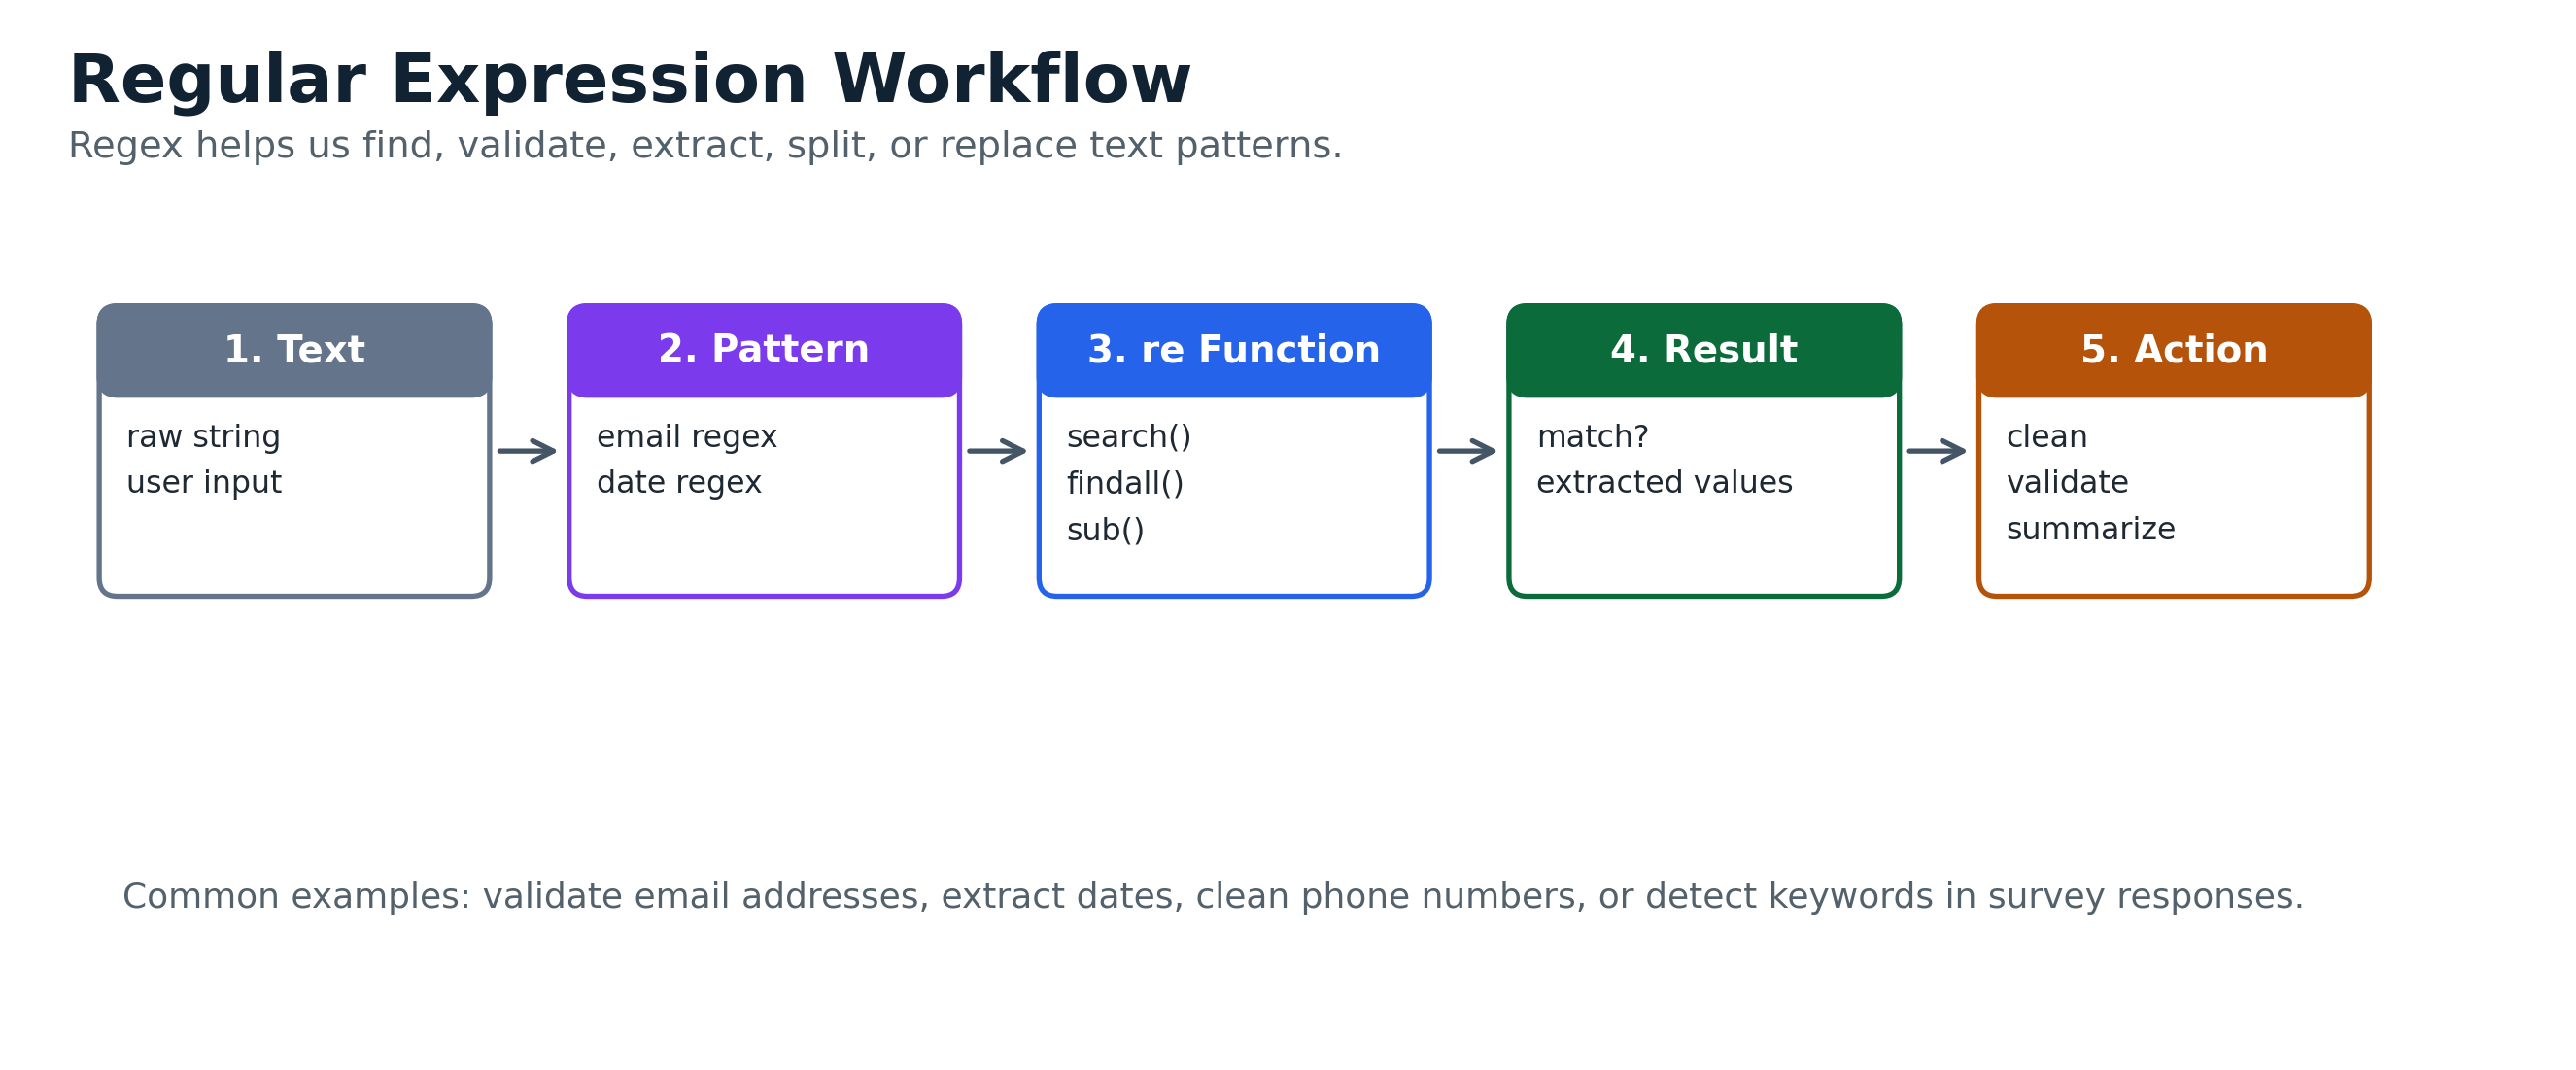<p class="figcap">Regular expression workflow for text validation and extraction.</p></div>

## Basic Regex Search


In [ ]:
import re

text = "Contact us at student@unt.edu"
pattern = r"\w+@\w+\.\w+"

match = re.search(pattern, text)

if match:
    print("Email found:", match.group())

## findall(): Extract All Matches


In [ ]:
import re

text = "Scores: 95, 88, 91, 100"
numbers = re.findall(r"\d+", text)

print(numbers)

## sub(): Replace Text


In [ ]:
import re

text = "My phone number is 940-123-4567."
cleaned = re.sub(r"\d", "X", text)

print(cleaned)

## Real Application Example: Validate UNT Email Format


In [ ]:
import re

emails = ["alice@unt.edu", "bob@gmail.com", "carla@unt.edu"]

for email in emails:
    if re.search(r"^[\w.-]+@unt\.edu$", email):
        print(email, "is a UNT email.")
    else:
        print(email, "is not a UNT email.")

# Part 6. Recursion and Lambda Expression

**Assigned readings:**  
- [Recursion Function — DataFlair](https://data-flair.training/blogs/python-recursion-function/)  
- [Lambda Expression — DataFlair](https://data-flair.training/blogs/python-lambda-expression/)


## More Detail: When to Use Recursion and Lambda

**Recursion** is useful when a problem naturally contains smaller versions of itself, such as factorials, tree traversal, or nested structures. Every recursive function needs a **base case** to stop.

**Lambda expressions** are useful for short, one-line functions, especially with tools like `sorted()`, `map()`, and `filter()`. For complex logic, a normal `def` function is usually more readable.


<div class="figure">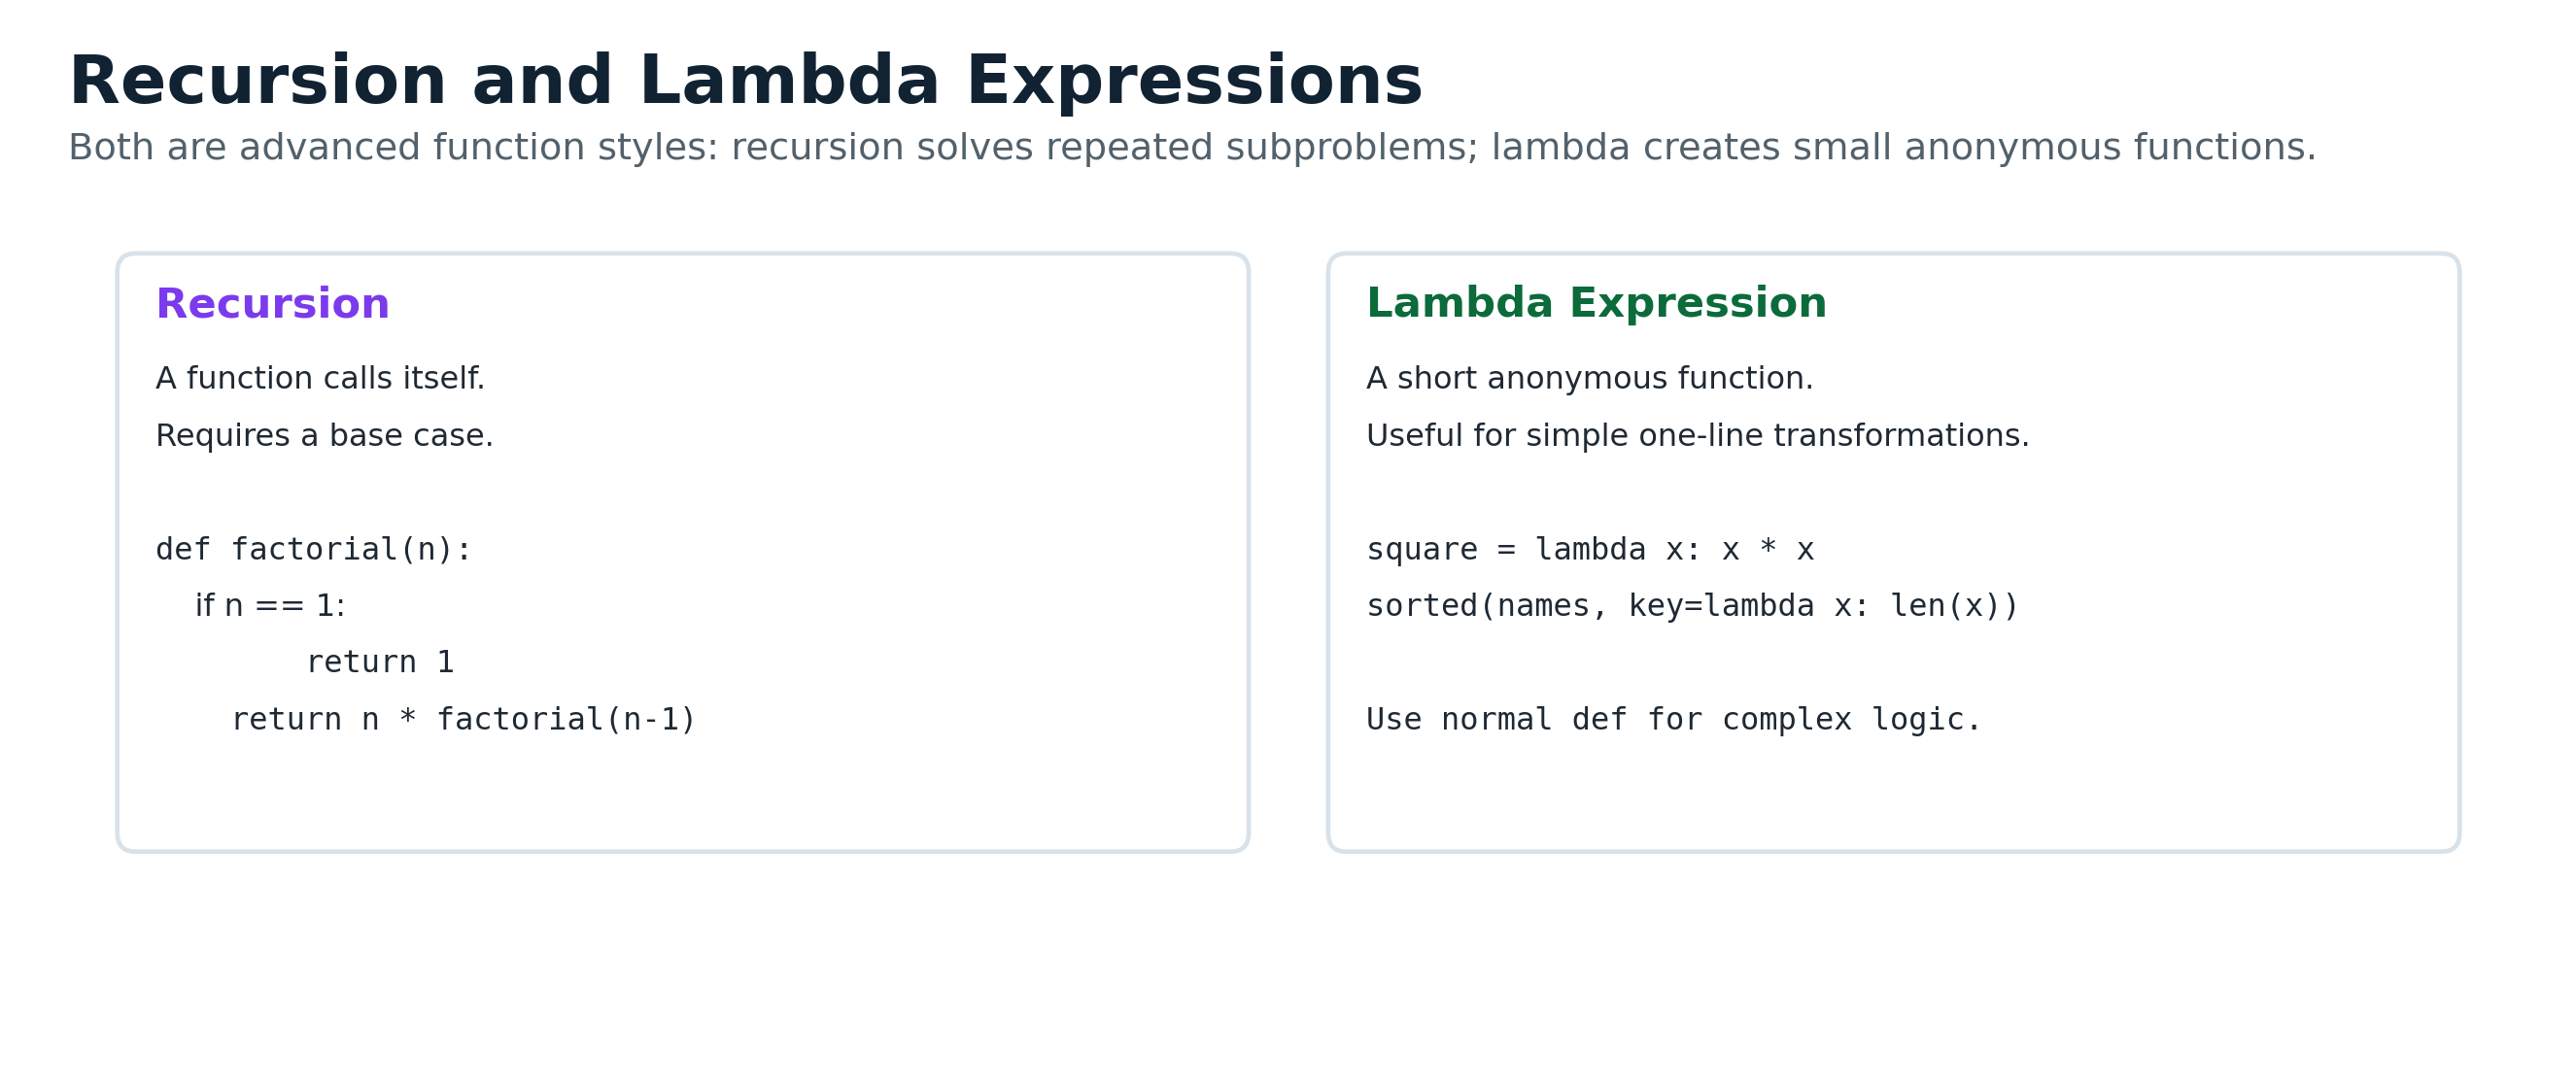<p class="figcap">Recursion and lambda expressions are advanced function styles.</p></div>

## Recursion

A recursive function calls itself. Every recursive function needs a base case.


In [ ]:
def countdown(n):
    if n <= 0:
        print("Done")
    else:
        print(n)
        countdown(n - 1)

countdown(5)

## Factorial Example


In [ ]:
def factorial(n):
    if n == 0 or n == 1:
        return 1
    return n * factorial(n - 1)

print(factorial(5))

## Lambda Expression

A lambda expression creates a small anonymous function.


In [ ]:
square = lambda x: x * x

print(square(5))

## Lambda with sorted()


In [ ]:
students = [
    {"name": "Alice", "score": 95},
    {"name": "Ben", "score": 88},
    {"name": "Carla", "score": 91}
]

sorted_students = sorted(students, key=lambda student: student["score"], reverse=True)

print(sorted_students)

# Part 7. Applied Mini Case Study: Course Data Helper

This mini case combines:

- functions
- arguments
- built-in functions
- `zip()`
- regular expressions
- dictionaries
- reusable workflow design

## More Detail: Why This Mini Case Matters

This mini case demonstrates a professional habit: instead of writing one long script, we organize logic into small reusable functions.

The workflow includes:

- `clean_score()` for input cleaning
- `is_unt_email()` for pattern validation
- `zip()` for combining related lists
- dictionaries for structured records

This is similar to how real data-processing and automation scripts are often organized.

In [ ]:
import re

def clean_score(raw_score):
    """Convert raw score text to an integer if possible."""
    try:
        score = int(raw_score)
        if 0 <= score <= 100:
            return score
        return None
    except ValueError:
        return None

def is_unt_email(email):
    """Return True if email appears to be a UNT email address."""
    return re.search(r"^[\w.-]+@unt\.edu$", email) is not None

names = ["Alice", "Ben", "Carla"]
raw_scores = ["95", "missing", "88"]
emails = ["alice@unt.edu", "ben@gmail.com", "carla@unt.edu"]

records = []

for name, raw_score, email in zip(names, raw_scores, emails):
    record = {
        "name": name,
        "score": clean_score(raw_score),
        "unt_email": is_unt_email(email)
    }
    records.append(record)

print(records)

## Summarize Valid Scores

In [ ]:
valid_scores = [record["score"] for record in records if record["score"] is not None]

if valid_scores:
    average = sum(valid_scores) / len(valid_scores)
    print("Average valid score:", round(average, 2))
else:
    print("No valid scores found.")

# Part 8. GenAI-Era Examples

## Example 1: Wrap AI-Generated Logic into a Function

When AI generates useful code, one way to improve it is to place the logic inside a well-named function.


In [ ]:
def validate_label(label):
    allowed_labels = {"positive", "neutral", "negative"}
    return label in allowed_labels

ai_labels = ["positive", "unknown", "negative"]

for label in ai_labels:
    print(label, "valid?", validate_label(label))

## Example 2: Use Regex to Validate AI Output Format


In [ ]:
import re

ai_answer = "Final score: 87"

match = re.search(r"Final score: (\d+)", ai_answer)

if match:
    score = int(match.group(1))
    print("Extracted score:", score)
else:
    print("AI answer did not follow the expected format.")

## Example 3: Avoid eval() on AI-Generated Code

This cell demonstrates a safer mindset: treat AI-generated text as untrusted unless verified.


In [ ]:
ai_expression = "2 + 3 * 4"

# This works, but should only be used with trusted expressions:
print(eval(ai_expression))

# Safer beginner mindset:
# Prefer writing the calculation directly or parsing allowed operations explicitly.
result = 2 + 3 * 4
print(result)

# Part 9. In-Class Activities

## Activity 1: Write a Reusable Grade Function


In [ ]:
def letter_grade(score):
    if score >= 90:
        return "A"
    elif score >= 80:
        return "B"
    elif score >= 70:
        return "C"
    elif score >= 60:
        return "D"
    else:
        return "F"

print(letter_grade(88))

## Activity 2: Pair Names and Scores with zip()


In [ ]:
names = ["Alice", "Ben", "Carla"]
scores = [95, 88, 91]

for name, score in zip(names, scores):
    print(f"{name}: {score}")

## Activity 3: Extract Numbers from Text with Regex


In [ ]:
import re

text = "Assignment scores are 95, 88, and 91."
numbers = re.findall(r"\d+", text)

print(numbers)

## Activity 4: Sort Records with Lambda


In [ ]:
students = [
    {"name": "Alice", "score": 95},
    {"name": "Ben", "score": 88},
    {"name": "Carla", "score": 91}
]

students_sorted = sorted(students, key=lambda x: x["score"], reverse=True)

print(students_sorted)

# Part 10. Click-to-Reveal Quiz

Try each question first, then click to reveal the answer.

<div class="quiz">
<p><b>Question 1. Which keyword defines a function in Python?</b></p>

- A. function
- B. def
- C. lambda only
- D. import

<details>
<summary><b>Click to reveal answer</b></summary>

<b>Answer:</b> B. def

<br><br><b>Explanation:</b> Python uses the `def` keyword to define a named function.
</details>
</div>

<div class="quiz">
<p><b>Question 2. What does `return` do?</b></p>

- A. Prints a value only
- B. Stops the function and sends back a result
- C. Imports a module
- D. Creates a package

<details>
<summary><b>Click to reveal answer</b></summary>

<b>Answer:</b> B. Stops the function and sends back a result

<br><br><b>Explanation:</b> A return statement ends the function and gives a result back to the caller.
</details>
</div>

<div class="quiz">
<p><b>Question 3. What does `zip()` do?</b></p>

- A. Compresses files
- B. Pairs items from sequences
- C. Deletes a function
- D. Runs a regex

<details>
<summary><b>Click to reveal answer</b></summary>

<b>Answer:</b> B. Pairs items from sequences

<br><br><b>Explanation:</b> `zip()` combines items from multiple sequences into pairs or tuples.
</details>
</div>

<div class="quiz">
<p><b>Question 4. Why should `eval()` and `exec()` be used carefully?</b></p>

- A. They cannot run code
- B. They can execute unsafe code from strings
- C. They only work with lists
- D. They create virtual environments

<details>
<summary><b>Click to reveal answer</b></summary>

<b>Answer:</b> B. They can execute unsafe code from strings

<br><br><b>Explanation:</b> Both functions can run code stored in strings, which is dangerous with untrusted input.
</details>
</div>

<div class="quiz">
<p><b>Question 5. Which module is commonly used for regular expressions?</b></p>

- A. datetime
- B. random
- C. re
- D. math

<details>
<summary><b>Click to reveal answer</b></summary>

<b>Answer:</b> C. re

<br><br><b>Explanation:</b> Python's `re` module provides regular expression functions.
</details>
</div>

<div class="quiz">
<p><b>Question 6. What is a recursive function?</b></p>

- A. A function that imports a package
- B. A function that calls itself
- C. A function without arguments
- D. A built-in function only

<details>
<summary><b>Click to reveal answer</b></summary>

<b>Answer:</b> B. A function that calls itself

<br><br><b>Explanation:</b> Recursion occurs when a function calls itself and uses a base case to stop.
</details>
</div>

<div class="quiz">
<p><b>Question 7. What does a lambda expression create?</b></p>

- A. A package
- B. A small anonymous function
- C. A virtual environment
- D. A regular expression module

<details>
<summary><b>Click to reveal answer</b></summary>

<b>Answer:</b> B. A small anonymous function

<br><br><b>Explanation:</b> A lambda expression creates a short function without defining it with a regular `def` statement.
</details>
</div>

# Part 11. Exit Ticket

Before the next class, answer these questions:

1. What is the purpose of a function?
2. What is the difference between a parameter and an argument?
3. What does `return` do?
4. What is one useful built-in function you used today?
5. What does `zip()` help us do?
6. Why are `eval()` and `exec()` risky?
7. What is one use of regular expressions?
8. Why does a recursive function need a base case?
9. When might a lambda expression be useful?

# Week 6 Summary

Today we covered:

- Defining and calling functions
- Function parameters, arguments, and return values
- Positional, keyword, default, `*args`, and `**kwargs`
- Common built-in functions
- `zip()`
- `repr()`
- `eval()`, `exec()`, and safety concerns
- Regular expression functions
- Recursion
- Lambda expressions
- Applied and GenAI-era examples

## Next Week

**Week 7: Modular Programming and Libraries**

# Complete Source List and Credits

## Assigned Week 6 Sources

1. [Introduction to Function — DataFlair](https://data-flair.training/blogs/python-function/)  
2. [Function Arguments — DataFlair](https://data-flair.training/blogs/python-function-arguments/)  
3. [Built-In Functions — DataFlair](https://data-flair.training/blogs/python-built-in-functions/)  
4. [Zip Function — DataFlair](https://data-flair.training/blogs/python-zip-function/)  
5. [eval Function — DataFlair](https://data-flair.training/blogs/python-eval-function/)  
6. [exec Function — DataFlair](https://data-flair.training/blogs/python-exec-function/)  
7. [repr Function — DataFlair](https://data-flair.training/blogs/python-repr-function/)  
8. [Regular Expression Functions — DataFlair](https://data-flair.training/blogs/python-regex-tutorial/)  
9. [Recursion Function — DataFlair](https://data-flair.training/blogs/python-recursion-function/)  
10. [Lambda Expression — DataFlair](https://data-flair.training/blogs/python-lambda-expression/)

## Additional References

- [Python Official Documentation — Functions](https://docs.python.org/3/tutorial/controlflow.html#defining-functions)
- [Python Official Documentation — Regular Expression HOWTO](https://docs.python.org/3/howto/regex.html)

## Diagram Credits

The diagrams retained in this notebook are instructor-created embedded PNG figures based on the assigned readings above.